In [117]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [118]:
nr_of_seeds = 10 #nr of seeds in the experiments

In [119]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [120]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12196\1466190064.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12196\1466190064.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

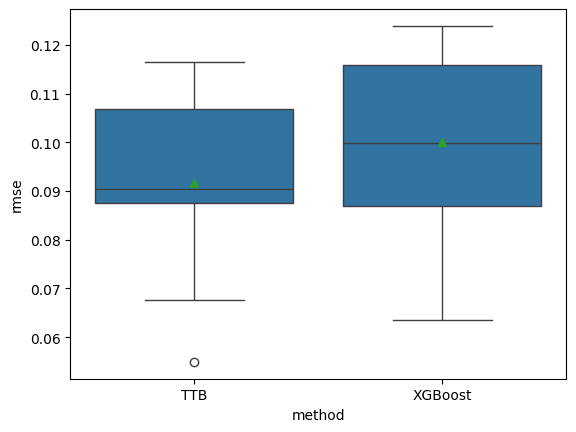

In [121]:


dat = pd.read_csv(f'results/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [122]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
44,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,850.0,400.0,0.063146,0.049028,0.054920,0.043514,TransferTreeBoost
627,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,858.0,400.0,0.098161,0.079186,0.067602,0.048338,TransferTreeBoost
108,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,851.0,400.0,0.089689,0.075327,0.111717,0.075991,TransferTreeBoost
572,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,857.0,400.0,0.060492,0.046144,0.108637,0.088004,TransferTreeBoost
155,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,852.0,400.0,0.091197,0.069700,0.091736,0.069151,TransferTreeBoost
340,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,854.0,400.0,0.099602,0.076296,0.116522,0.085447,TransferTreeBoost
419,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,855.0,400.0,0.074645,0.062014,0.087329,0.055404,TransferTreeBoost
484,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,856.0,400.0,0.102230,0.065652,0.101396,0.077896,TransferTreeBoost
692,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,859.0,400.0,0.061533,0.055096,0.088446,0.060426,TransferTreeBoost
284,0.1,1.0,1.0,0.01,0.9,0.091743,0.066768,10,853.0,400.0,0.105060,0.073235,0.089129,0.063514,TransferTreeBoost


In [123]:
lk

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2,0.1,3.0,0.100141,0.069835,10,2,850.0,0.071169,0.055832,0.063565,0.045839,XGBoost
8,0.1,3.0,0.100141,0.069835,10,8,851.0,0.113134,0.088715,0.094289,0.064919,XGBoost
14,0.1,3.0,0.100141,0.069835,10,14,852.0,0.096745,0.061683,0.116246,0.088290,XGBoost
20,0.1,3.0,0.100141,0.069835,10,20,853.0,0.126901,0.085076,0.099439,0.059993,XGBoost
26,0.1,3.0,0.100141,0.069835,10,26,854.0,0.103405,0.082738,0.115051,0.080682,XGBoost
44,0.1,3.0,0.100141,0.069835,10,44,857.0,0.068740,0.056369,0.084382,0.065168,XGBoost
38,0.1,3.0,0.100141,0.069835,10,38,856.0,0.118197,0.083349,0.100479,0.067081,XGBoost
32,0.1,3.0,0.100141,0.069835,10,32,855.0,0.095271,0.079129,0.123078,0.065630,XGBoost
50,0.1,3.0,0.100141,0.069835,10,50,858.0,0.101787,0.085912,0.080964,0.067976,XGBoost
56,0.1,3.0,0.100141,0.069835,10,56,859.0,0.059345,0.053871,0.123920,0.092775,XGBoost
